# Projet Python avancé : Suivi temporel du NDVI 

Realise par Med-K-100010

## 1- Installation et imports des bibliotheques 


In [5]:
# !pip install ee geemap requests beautifulsoup4 rasterio pandas numpy matplotlib

import os
import re
import json
import sqlite3
from pathlib import Path
from datetime import datetime
from urllib.parse import urljoin

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import rasterio
from rasterio.mask import mask

import ee
import geemap


## 2- Authentification Google Earth Engine


In [6]:
#Il nous permet de nous connecter à notre compte Google Earth Engine et d'initialiser l'environnement pour accéder aux données et fonctionnalités de GEE.
ee.Authenticate()
ee.Initialize(project="my-project-01-492711")


## 3- Parcelle d’étude et paramètres


In [ ]:
#Définition de la géométrie de la parcelle d'étude (AOI) à partir du GeoJSON fourni. Cette géométrie sera utilisée pour extraire les données NDVI spécifiques à cette zone d'intérêt
parcel_geojson = {
    "type": "Polygon",
    "coordinates": [[
            [
              -5.7276087800704545,
              34.408955036368155
            ],
            [
              -5.72740872835459,
              34.39941401356819
            ],
            [
              -5.7238863820088,
              34.39634332081883
            ],
            [
              -5.721228150626246,
              34.39579498186836
            ],
            [
              -5.718902194064896,
              34.39458863515661
            ],
            [
              -5.715579444458115,
              34.391408259818974
            ],
            [
              -5.715911787115488,
              34.40171702714579
            ],
            [
              -5.709399247436295,
              34.40193635857878
            ],
            [
              -5.7093331016170055,
              34.39612444649437
            ],
            [
              -5.703285220790633,
              34.40040104997972
            ],
            [
              -5.703285023464218,
              34.40199119382538
            ],
            [
              -5.701357601407608,
              34.40204602897843
            ],
            [
              -5.697171292313044,
              34.411312121904515
            ],
            [
              -5.703550211504648,
              34.409393744770355
            ],
            [
              -5.7276087800704545,
              34.408955036368155
            ]
          ]]
}

AOI = ee.Geometry.Polygon(parcel_geojson["coordinates"])

#Ici j'ai defini ces variables pour stocker le nom de la région d'étude et mon nom qui seront stockés dans la base de données.
region_name = "Rabat-Salé-Kénitra"
student_name = "Med-K-100010"
#Ici les dates de début et de fin de la période d'étude pour laquelle nous allons extraire les données NDVI. La date de début est fixée au 1er septembre 2025, tandis que la date de fin est définie comme la date actuelle au moment de l'exécution du code.
start_date = "2025-09-01"
end_date = datetime.today().strftime("%Y-%m-%d")


## 4- Visualisation de la parcelle


In [8]:
#uniquement la visualisation de la parcelle d'étude sur une carte interactive à l'aide de la bibliothèque geemap.
Map = geemap.Map(center=[34.401, -5.714], zoom=13)
Map.addLayer(AOI, {"color": "red"}, "Parcelle")
Map


Map(center=[34.401, -5.714], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

## 5- Extraction NDVI depuis Google Earth Engine


In [9]:
#Cette fonction calcule l'indice de végétation par différence normalisée (NDVI) pour chaque image de la collection Sentinel-2. Le NDVI est calculé en utilisant les bandes B8 (infrarouge proche) et B4 (rouge) de l'image, puis ajouté en tant que nouvelle bande nommée "NDVI" à l'image d'origine.
def add_ndvi(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    return image.addBands(ndvi)
#Cette partie du code crée une collection d'images Sentinel-2 à partir de Google Earth Engine, filtrée par la zone d'intérêt (AOI), les dates spécifiées, et un seuil de pourcentage de pixels nuageux inférieur à 10%. Ensuite, la fonction add_ndvi est appliquée à chaque image de la collection pour calculer et ajouter la bande NDVI.
gee_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(AOI)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
    .map(add_ndvi)
)
#Cette fonction extract_gee_stats extrait les statistiques de la bande NDVI pour chaque image de la collection. Elle utilise la méthode reduceRegion pour calculer la moyenne, la médiane, le minimum, le maximum et l'écart type du NDVI dans la zone d'intérêt (AOI). Les résultats sont ensuite stockés dans une feature avec des propriétés supplémentaires telles que la date de l'image et la source des données (GEE).
def extract_gee_stats(image):
    stats = image.select("NDVI").reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(ee.Reducer.median(), "", True)
            .combine(ee.Reducer.min(), "", True)
            .combine(ee.Reducer.max(), "", True)
            .combine(ee.Reducer.stdDev(), "", True)
        ),
        geometry=AOI,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    )
    return ee.Feature(None, stats).set({
        "date_image": image.date().format("YYYY-MM-dd"),
        "source": "GEE"
    })

gee_features = gee_collection.map(extract_gee_stats)
#Cette fonction ee_feature_collection_to_df convertit une collection de features de Google Earth Engine en un DataFrame pandas. Elle itère sur les features de la collection, extrait les propriétés pertinentes (date de l'image, statistiques NDVI, source), et les stocke dans une liste de dictionnaires. Enfin, cette liste est convertie en un DataFrame pour une analyse et une visualisation ultérieures.
def ee_feature_collection_to_df(fc):
    data = fc.getInfo()
    rows = []
    for f in data["features"]:
        p = f["properties"]
        rows.append({
            "date_image": p.get("date_image"),
            "ndvi_moyen": p.get("NDVI_mean"),
            "ndvi_median": p.get("NDVI_median"),
            "ndvi_min": p.get("NDVI_min"),
            "ndvi_max": p.get("NDVI_max"),
            "ndvi_std": p.get("NDVI_stdDev"),
            "source": p.get("source", "GEE")
        })
    return pd.DataFrame(rows)
#Enfin, la collection de features extraite de Google Earth Engine est convertie en un DataFrame pandas à l'aide de la fonction ee_feature_collection_to_df, et les premières lignes du DataFrame sont affichées pour vérifier les résultats.
gee_df = ee_feature_collection_to_df(gee_features)
gee_df.head()


,date_image,ndvi_moyen,ndvi_median,ndvi_min,ndvi_max,ndvi_std,source
0,2025-09-02,0.590523,0.613319,-0.521222,0.860173,0.147994,GEE
1,2025-09-02,0.594718,0.613241,-0.564767,0.869295,0.151568,GEE
2,2025-09-04,0.558898,0.574232,-0.479053,0.806833,0.135524,GEE
3,2025-09-04,0.569051,0.589940,-0.642192,0.826638,0.145328,GEE
4,2025-09-12,0.588140,0.605370,-0.536280,0.860916,0.146661,GEE


On peut voir des valeur de ndvi variant entre -1 et 1, les valeurs negatives representent generalement de l'eau ou des nuages qui faussent les resultats, les valeurs nulles sont caracteristiques du sol nu et superieur a 0 correspond a la vegetation soit faible ou morte ou encore dense.
Comme nos etudes on portees sur une periode pluvieuse alors on trouves des valeurs de ndvi elevees sans oublier que les plantes grandissent et par consequent le ndvi augmente aussi.

## 6- Base de données SQLite
ici creer la base de donnees ou seront stockees nos donnees


In [10]:
#connection à la base de données SQLite et création des tables nécessaires pour stocker les informations sur les parcelles
db_file = Path("kaba_mohamed.db")
conn = sqlite3.connect(db_file)
cur = conn.cursor()

#creation de la table "parcelles" pour stocker les informations sur les parcelles d'étude
cur.execute("""
CREATE TABLE IF NOT EXISTS parcelles (
    id_parcelle INTEGER PRIMARY KEY AUTOINCREMENT,
    nom_etudiant TEXT NOT NULL,
    region TEXT NOT NULL,
    geom TEXT NOT NULL
)
""")

#creation de la table "ndvi_gee" pour stocker les statistiques NDVI extraites de Google Earth Engine pour chaque parcelle et chaque date d'image
cur.execute("""
CREATE TABLE IF NOT EXISTS ndvi_gee (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    id_parcelle INTEGER NOT NULL,
    date_image TEXT NOT NULL,
    ndvi_moyen REAL,
    ndvi_median REAL,
    ndvi_min REAL,
    ndvi_max REAL,
    ndvi_std REAL,
    source TEXT DEFAULT 'GEE',
    FOREIGN KEY(id_parcelle) REFERENCES parcelles(id_parcelle)
)
""")

#creation de la table "ndvi_modis" pour stocker les statistiques NDVI extraites de MODIS pour chaque parcelle et chaque date d'image
cur.execute("""
CREATE TABLE IF NOT EXISTS ndvi_modis (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    id_parcelle INTEGER NOT NULL,
    date_carte TEXT NOT NULL,
    ndvi_moyen REAL,
    ndvi_median REAL,
    ndvi_min REAL,
    ndvi_max REAL,
    ndvi_std REAL,
    source TEXT DEFAULT 'MODIS',
    file_path TEXT,
    FOREIGN KEY(id_parcelle) REFERENCES parcelles(id_parcelle)
)
""")

#creation de la table "comparaison_ndvi" pour stocker les résultats de la comparaison entre les données NDVI extraites de GEE et MODIS pour chaque parcelle et chaque date d'image
cur.execute("""
CREATE TABLE IF NOT EXISTS comparaison_ndvi (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    id_parcelle INTEGER NOT NULL,
    date_gee TEXT NOT NULL,
    date_modis TEXT NOT NULL,
    ecart_jours INTEGER,
    ndvi_moy_gee REAL,
    ndvi_moy_modis REAL,
    ndvi_med_gee REAL,
    ndvi_med_modis REAL,
    erreur_moy REAL,
    erreur_med REAL,
    rmse REAL,
    FOREIGN KEY(id_parcelle) REFERENCES parcelles(id_parcelle)
)
""")

conn.commit()

#Insertion des informations sur le nom de l'étudiant, la région d'étude et la géométrie de la parcelle dans la table "parcelles" de la base de données SQLite. Avant d'insérer les données, le code vérifie si la table "parcelles" est vide en comptant le nombre d'enregistrements. Si la table est vide, les informations sont insérées et la transaction est validée avec conn.commit().
cur.execute("SELECT COUNT(*) FROM parcelles")
if cur.fetchone()[0] == 0:
    cur.execute(
        "INSERT INTO parcelles (nom_etudiant, region, geom) VALUES (?, ?, ?)",
        (student_name, region_name, json.dumps(parcel_geojson, ensure_ascii=False))
    )
    conn.commit()
#l'identifiant de la parcelle nouvellement insérée est récupéré pour être utilisé dans les tables suivantes
id_parcelle = cur.execute(
    "SELECT id_parcelle FROM parcelles ORDER BY id_parcelle DESC LIMIT 1"
).fetchone()[0]
id_parcelle


1

Ici ce code cree directement la base de donnees meme si le fichier n'est pas fournis donc le seul script python est suffisant

In [11]:
#Insertion des statistiques NDVI extraites de Google Earth Engine dans la table "ndvi_gee" de la base de données SQLite. Chaque enregistrement est associé à l'identifiant de la parcelle, à la date de l'image, et aux différentes statistiques calculées (moyenne, médiane, minimum, maximum, écart type). La date de l'image est convertie au format "YYYY-MM-DD" avant d'être insérée dans la base de données.
gee_df["id_parcelle"] = id_parcelle
gee_df["date_image"] = pd.to_datetime(gee_df["date_image"]).dt.strftime("%Y-%m-%d")
gee_df.to_sql("ndvi_gee", conn, if_exists="append", index=False)
pd.read_sql("SELECT * FROM ndvi_gee LIMIT 5", conn)


,id,id_parcelle,date_image,ndvi_moyen,ndvi_median,ndvi_min,ndvi_max,ndvi_std,source
0,1,1,2025-09-02,0.590523,0.613319,-0.521222,0.860173,0.147994,GEE
1,2,1,2025-09-02,0.594718,0.613241,-0.564767,0.869295,0.151568,GEE
2,3,1,2025-09-04,0.558898,0.574232,-0.479053,0.806833,0.135524,GEE
3,4,1,2025-09-04,0.569051,0.589940,-0.642192,0.826638,0.145328,GEE
4,5,1,2025-09-12,0.588140,0.605370,-0.536280,0.860916,0.146661,GEE


Ici c'est la connection avec la base de donnees des stats de GEE

## 7- Téléchargement automatique des cartes MODIS


In [12]:
MODIS_ROOT_URL = "http://www.cgms-maroc.ma/Modis/ndvi/"
MODIS_DIR = Path("modis_data")
MODIS_DIR.mkdir(exist_ok=True)
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"
}
START_DATE = datetime(2025, 9, 1)
#Cette fonction safe_filename prend un nom de fichier en entrée et utilise une expression régulière pour remplacer tous les caractères qui ne sont pas des lettres, des chiffres, des points, des tirets ou des underscores par des underscores.
def safe_filename(name):
    return re.sub(r"[^\w.\-]+", "_", name)
#Cette fonction list_date_folders récupère la liste des dossiers de date disponibles sur le serveur MODIS en effectuant une requête HTTP GET à l'URL racine. Elle utilise BeautifulSoup pour analyser le contenu HTML de la page et extraire les liens vers les dossiers de date qui correspondent au format "YYYY.MM.DD/".
def list_date_folders(root_url):
    resp = requests.get(root_url, headers=HEADERS, timeout=60)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")
    folders = []
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        if re.fullmatch(r"\d{4}\.\d{2}\.\d{2}/", href):
            folders.append(href)
    return sorted(set(folders))

#Cette fonction list_ndvi_files prend l'URL d'un dossier de date spécifique sur le serveur MODIS et récupère la liste des fichiers NDVI disponibles dans ce dossier. Elle effectue une requête HTTP GET à l'URL du dossier, analyse le contenu HTML avec BeautifulSoup, et extrait les liens vers les fichiers qui commencent par "ndvi" et se terminent par ".tif", ".tiff" ou ".img".
def list_ndvi_files(folder_url):
    resp = requests.get(folder_url, headers=HEADERS, timeout=60)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")
    files = []
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        low = href.lower()
        if low.startswith("ndvi") and (low.endswith(".tif") or low.endswith(".tiff") or low.endswith(".img")):
            files.append(href)
    return sorted(set(files))

#Cette fonction download_file télécharge un fichier à partir d'une URL donnée et le sauvegarde à un chemin de destination spécifié. Avant de télécharger, elle vérifie si le fichier existe déjà et a une taille supérieure à zéro pour éviter les téléchargements redondants. Si le téléchargement est nécessaire, elle effectue une requête HTTP GET avec streaming pour télécharger le fichier par morceaux et l'écrire en mode binaire.
def download_file(file_url, dest_path):
    dest_path.parent.mkdir(parents=True, exist_ok=True)
    if dest_path.exists() and dest_path.stat().st_size > 0:
        return False
    with requests.get(file_url, headers=HEADERS, timeout=120, stream=True) as r:
        r.raise_for_status()
        with open(dest_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 128):
                if chunk:
                    f.write(chunk)
    return True

#Le code principal parcourt les dossiers de date disponibles sur le serveur MODIS, filtre ceux qui sont postérieurs à la date de début spécifiée, et pour chaque dossier de date retenu, il récupère la liste des fichiers NDVI disponibles. Ensuite, il télécharge chaque fichier NDVI dans un dossier local structuré par date, en utilisant la fonction download_file. Les chemins des fichiers téléchargés sont stockés dans une liste downloaded_files pour un suivi ultérieur.
downloaded_files = []
date_folders = list_date_folders(MODIS_ROOT_URL)
date_folders = [f for f in date_folders if datetime.strptime(f.strip("/"), "%Y.%m.%d") >= START_DATE]

print("Dossiers date retenus :", len(date_folders))

for folder in date_folders:
    folder_url = urljoin(MODIS_ROOT_URL, folder)
    try:
        ndvi_files = list_ndvi_files(folder_url)
    except Exception as e:
        print(f"[ERREUR] lecture du dossier {folder_url} : {e}")
        continue

    local_folder = MODIS_DIR / folder.strip("/")
    local_folder.mkdir(parents=True, exist_ok=True)

    for filename in ndvi_files:
        file_url = urljoin(folder_url, filename)
        dest_path = local_folder / safe_filename(filename)
        try:
            created = download_file(file_url, dest_path)
            if created:
                downloaded_files.append(str(dest_path))
                print("Téléchargé :", dest_path)
        except Exception as e:
            print(f"[ERREUR] téléchargement impossible {file_url} : {e}")

print("Nombre total de fichiers NDVI téléchargés :", len(downloaded_files))


Dossiers date retenus : 27
Nombre total de fichiers NDVI téléchargés : 0


Ce telechargement ne retechargera pas les fichiers une fois deja telecharges 

## 8- Extraction des valeurs MODIS à l’intérieur de la parcelle


In [13]:
from rasterio.mask import mask
from rasterio.warp import transform_geom

#Cette fonction compute_modis_stats prend en entrée le chemin d'un fichier raster MODIS et la géométrie de la parcelle d'étude au format GeoJSON. Elle ouvre le fichier raster avec rasterio, effectue une découpe (mask) du raster en utilisant la géométrie de la parcelle, et calcule les statistiques NDVI (moyenne, médiane, minimum, maximum, écart type) à partir des valeurs du raster découpé. Les résultats sont retournés sous forme de dictionnaire.
def compute_modis_stats(file_path, geom_geojson):
    with rasterio.open(file_path) as src:
        try:
            # 🔥 reprojection automatique
            geom_proj = transform_geom("EPSG:4326", src.crs, geom_geojson)
            #Ici on decoupe notre parcelle de la carte modis pour extraire les valeurs de NDVI correspondantes à notre parcelle d'étude.
            clipped, _ = mask(src, [geom_proj], crop=True)
        except Exception as e:
            print("Erreur mask:", file_path, e)
            return None

        band = clipped[0].astype("float64")
        #Ici on divise les valeurs du NDVI par 10000 pour les normaliser, car les données MODIS sont souvent stockées sous forme d'entiers où le NDVI est multiplié par 10000 pour préserver la précision.
        band = band / 10000.0
        
        # gestion nodata
        if src.nodata is not None:
            band[band == src.nodata] = np.nan

        band = band[np.isfinite(band)]

        if band.size == 0:
            print("Aucune donnée dans la parcelle:", file_path)
            return None

        return {
            "ndvi_moyen": float(np.nanmean(band)),
            "ndvi_median": float(np.nanmedian(band)),
            "ndvi_min": float(np.nanmin(band)),
            "ndvi_max": float(np.nanmax(band)),
            "ndvi_std": float(np.nanstd(band))
        }

modis_rows = []

#  boucle par dossier (date)
for date_folder in sorted(MODIS_DIR.iterdir()):
    if not date_folder.is_dir():
        continue

    date_str = date_folder.name  # ex: 2025.09.15

    #  trouver le fichier NDVI dans le dossier
    ndvi_files = [
        f for f in date_folder.iterdir()
        if f.is_file() and f.name.lower().startswith("ndvi")
        and f.suffix.lower() in [".tif", ".tiff", ".img"]
    ]

    if not ndvi_files:
        print("Aucun fichier NDVI dans:", date_folder)
        continue

    # prendre le premier fichier NDVI
    raster_path = ndvi_files[0]

    stats = compute_modis_stats(raster_path, parcel_geojson)

    if stats is not None:
        modis_rows.append({
            "id_parcelle": id_parcelle,
            "date_carte": date_str,
            **stats,
            "source": "MODIS",
            "file_path": str(raster_path)
        })

#Insertion des statistiques NDVI extraites de MODIS dans la table "ndvi_modis" de la base de données SQLite
modis_df = pd.DataFrame(modis_rows)
modis_df["date_carte"] = pd.to_datetime(modis_df["date_carte"], format="%Y.%m.%d")
print("Nombre de dates MODIS extraites :", len(modis_df))
modis_df.head()

Nombre de dates MODIS extraites : 27


,id_parcelle,date_carte,ndvi_moyen,ndvi_median,ndvi_min,ndvi_max,ndvi_std,source,file_path
0,1,2025-09-06,0.240368,0.0,0.0,0.8197,0.330683,MODIS,modis_data\2025.09.06\ndvi2025.09.06.tiff
1,1,2025-09-14,0.222145,0.0,0.0,0.7568,0.304731,MODIS,modis_data\2025.09.14\ndvi2025.09.14.tiff
2,1,2025-09-22,0.217916,0.0,0.0,0.7463,0.299562,MODIS,modis_data\2025.09.22\ndvi2025.09.22.tiff
3,1,2025-09-30,0.221480,0.0,0.0,0.7205,0.304624,MODIS,modis_data\2025.09.30\ndvi2025.09.30.tiff
4,1,2025-10-08,0.232988,0.0,0.0,0.7886,0.320093,MODIS,modis_data\2025.10.08\ndvi2025.10.08.tiff


On voit pour les stats obtenus des cartes modis que le ndvi min et median sont nulles peut etre parceque le modis ne fais pas beaucoup d'enregistrement et les valeurs non existantes sont remplacees par 0 ce qui donne ces resultats

In [14]:
if not modis_df.empty:
    modis_df.to_sql("ndvi_modis", conn, if_exists="append", index=False)

pd.read_sql("SELECT * FROM ndvi_modis LIMIT 5", conn)


,id,id_parcelle,date_carte,ndvi_moyen,ndvi_median,ndvi_min,ndvi_max,ndvi_std,source,file_path
0,1,1,2025-09-06 00:00:00,0.240368,0.0,0.0,0.8197,0.330683,MODIS,modis_data\2025.09.06\ndvi2025.09.06.tiff
1,2,1,2025-09-14 00:00:00,0.222145,0.0,0.0,0.7568,0.304731,MODIS,modis_data\2025.09.14\ndvi2025.09.14.tiff
2,3,1,2025-09-22 00:00:00,0.217916,0.0,0.0,0.7463,0.299562,MODIS,modis_data\2025.09.22\ndvi2025.09.22.tiff
3,4,1,2025-09-30 00:00:00,0.221480,0.0,0.0,0.7205,0.304624,MODIS,modis_data\2025.09.30\ndvi2025.09.30.tiff
4,5,1,2025-10-08 00:00:00,0.232988,0.0,0.0,0.7886,0.320093,MODIS,modis_data\2025.10.08\ndvi2025.10.08.tiff


## 9- Appariement des dates GEE et MODIS (± 3 jours)


In [15]:
#Lecture des tables de la base de donnees ndvi_gee et ndvi_modis 
gee_db = pd.read_sql("SELECT * FROM ndvi_gee WHERE id_parcelle = ?", conn, params=(id_parcelle,))
modis_db = pd.read_sql("SELECT * FROM ndvi_modis WHERE id_parcelle = ?", conn, params=(id_parcelle,))

#Conversion des colonnes de date en format datetime pour faciliter la comparaison entre les dates des images GEE et MODIS. La colonne "date_image" du DataFrame gee_db est convertie en datetime, tandis que la colonne "date_carte" du DataFrame modis_db est également convertie en datetime avec une gestion des erreurs pour les formats de date invalides.
gee_db["date_image"] = pd.to_datetime(gee_db["date_image"])
modis_db["date_carte"] = pd.to_datetime(modis_db["date_carte"], errors="coerce")

#Comparaison des données NDVI extraites de GEE et MODIS pour trouver les paires d'images les plus proches en termes de date. Pour chaque image dans gee_db, le code calcule la différence absolue en jours entre la date de l'image GEE et les dates des cartes MODIS, puis trouve l'index de la carte MODIS la plus proche. Si l'écart en jours est inférieur ou égal à 3, une paire est créée avec les informations pertinentes (dates, statistiques NDVI, erreurs) et stockée dans une liste pairs.
#On a cree une liste vide 'pairs' ou on va stocker les elements de comparaison 
pairs = []

for _, g in gee_db.iterrows():
    if modis_db.empty:
        continue
    diffs = (modis_db["date_carte"] - g["date_image"]).abs()
    idx = diffs.idxmin()
    closest = modis_db.loc[idx]
    ecart = abs((closest["date_carte"] - g["date_image"]).days)
    if ecart <= 3:
        pairs.append({
            "id_parcelle": id_parcelle,
            "date_gee": g["date_image"].strftime("%Y-%m-%d"),
            "date_modis": closest["date_carte"].strftime("%Y-%m-%d"),
            "ecart_jours": int(ecart),
            "ndvi_moy_gee": g["ndvi_moyen"],
            "ndvi_moy_modis": closest["ndvi_moyen"],
            "ndvi_med_gee": g["ndvi_median"],
            "ndvi_med_modis": closest["ndvi_median"],
            "erreur_moy": g["ndvi_moyen"] - closest["ndvi_moyen"],
            "erreur_med": g["ndvi_median"] - closest["ndvi_median"],
            "rmse": float(np.sqrt((g["ndvi_moyen"] - closest["ndvi_moyen"]) ** 2))
        })

#Insertion dans une dataframe et affichage des 5 premieres lignes
comp_df = pd.DataFrame(pairs)
comp_df.head()


,id_parcelle,date_gee,date_modis,ecart_jours,ndvi_moy_gee,ndvi_moy_modis,ndvi_med_gee,ndvi_med_modis,erreur_moy,erreur_med,rmse
0,1,2025-09-04,2025-09-06,2,0.558898,0.240368,0.574232,0.0,0.318531,0.574232,0.318531
1,1,2025-09-04,2025-09-06,2,0.569051,0.240368,0.589940,0.0,0.328683,0.589940,0.328683
2,1,2025-09-12,2025-09-14,2,0.588140,0.222145,0.605370,0.0,0.365996,0.605370,0.365996
3,1,2025-09-12,2025-09-14,2,0.592720,0.222145,0.613460,0.0,0.370575,0.613460,0.370575
4,1,2025-09-14,2025-09-14,0,0.560809,0.222145,0.582085,0.0,0.338665,0.582085,0.338665


On observe des erreurs tres elevees a cause des valeurs min et median de modis qui posent probleme

In [16]:
#INSERTION DANS LA BASE DE DONNEES
if not comp_df.empty:
    comp_df.to_sql("comparaison_ndvi", conn, if_exists="append", index=False)

pd.read_sql("SELECT * FROM comparaison_ndvi LIMIT 5", conn)


,id,id_parcelle,date_gee,date_modis,ecart_jours,ndvi_moy_gee,ndvi_moy_modis,ndvi_med_gee,ndvi_med_modis,erreur_moy,erreur_med,rmse
0,1,1,2025-09-04,2025-09-06,2,0.558898,0.240368,0.574232,0.0,0.318531,0.574232,0.318531
1,2,1,2025-09-04,2025-09-06,2,0.569051,0.240368,0.589940,0.0,0.328683,0.589940,0.328683
2,3,1,2025-09-12,2025-09-14,2,0.588140,0.222145,0.605370,0.0,0.365996,0.605370,0.365996
3,4,1,2025-09-12,2025-09-14,2,0.592720,0.222145,0.613460,0.0,0.370575,0.613460,0.370575
4,5,1,2025-09-14,2025-09-14,0,0.560809,0.222145,0.582085,0.0,0.338665,0.582085,0.338665


## 10- Graphiques comparatifs


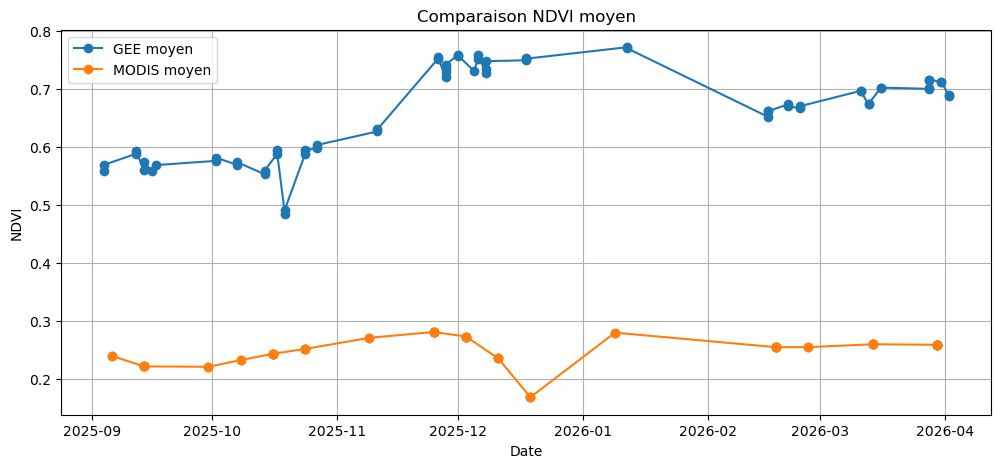

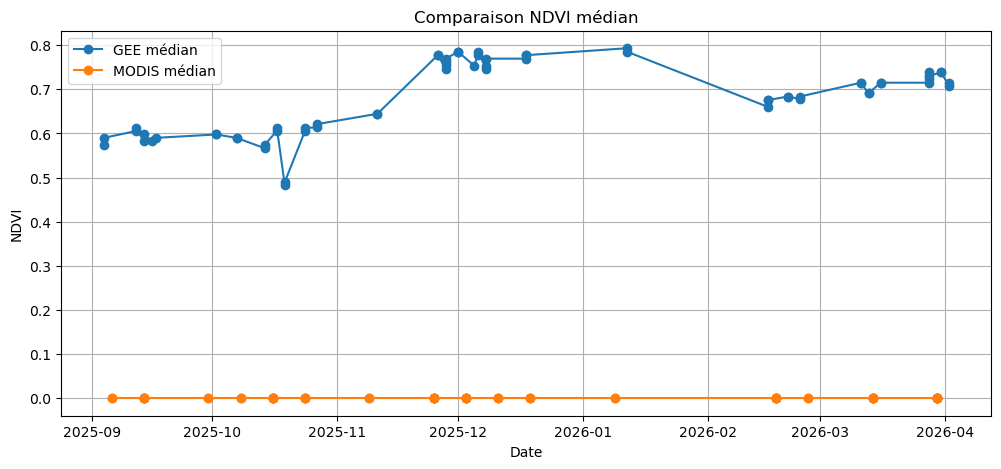

In [17]:
#Affichage des graphes de comparaison
if not comp_df.empty:
    comp_df["date_gee"] = pd.to_datetime(comp_df["date_gee"])
    comp_df["date_modis"] = pd.to_datetime(comp_df["date_modis"])

    plt.figure(figsize=(12, 5))
    plt.plot(comp_df["date_gee"], comp_df["ndvi_moy_gee"], marker="o", label="GEE moyen")
    plt.plot(comp_df["date_modis"], comp_df["ndvi_moy_modis"], marker="o", label="MODIS moyen")
    plt.title("Comparaison NDVI moyen")
    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(comp_df["date_gee"], comp_df["ndvi_med_gee"], marker="o", label="GEE médian")
    plt.plot(comp_df["date_modis"], comp_df["ndvi_med_modis"], marker="o", label="MODIS médian")
    plt.title("Comparaison NDVI médian")
    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Aucune paire de dates compatible n'a été trouvée.")


On voit que le GEE donnent des resultats plus precis que le modis qui pose beaucoup de problemes

## 11- Carte interactive de l’évolution du NDVI


In [18]:
ndvi_vis = {
    "min": 0.0,
    "max": 1.0,
    "palette": ["red", "yellow", "green"]
}

ndvi_collection_clipped = gee_collection.map(lambda image: image.clip(AOI))

Map = geemap.Map(center=[34.401, -5.714], zoom=13)
Map.add_time_slider(
    ndvi_collection_clipped.select("NDVI"),
    vis_params=ndvi_vis,
    time_interval=30,
    label="NDVI",
    name="NDVI Timeline"
)
Map.addLayer(AOI, {"color": "red", "fillColor": "00000000"}, "AOI")
Map


Map(center=[34.401, -5.714], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

Cette montre que la vegetation evolue bien avec le temps surement due a la periode pluvieuse recente et au stades vegetatifs des plantes

## 12- Export des tableaux


In [19]:
#Ce code exporte les DataFrames contenant les statistiques NDVI extraites de GEE et MODIS, ainsi que les résultats de la comparaison, au format CSV.
gee_db.to_csv("ndvi_gee.csv", index=False)
modis_db.to_csv("ndvi_modis.csv", index=False)
comp_df.to_csv("comparaison_ndvi.csv", index=False)

conn.close()
print("Export terminé.")


Export terminé.


## Suppression du contenu de toutes les tables creee pour recommencer a zero
supprimer les trois crochet ensuite executer le code pour ce faire 

In [ ]:
'''conn = sqlite3.connect(db_file)
cur = conn.cursor()

cur.execute("DELETE FROM comparaison_ndvi")
cur.execute("DELETE FROM ndvi_modis")
cur.execute("DELETE FROM ndvi_gee")
cur.execute("DELETE FROM parcelles")
cur.execute("DELETE FROM sqlite_sequence")

conn.commit()
conn.close()

print("Tables vidées avec succès")

Tables vidées avec succès
